---
title: Comparing SWOT HR and LR Water Surface Elevations — Bach Ice Shelf
date: 2026-09-14
github: https://github.com/cryointhecloud/CryocloudWebsite
subject: Tutorial
authors:
  - name: Derek Pickell
    affiliations:
      -  University of Maryland
    email: derekp@umd.edu
    corresponding: true
    github: derekpickell
  - name: Tasha Snow
    affiliations:
      - University of Maryland
      - NASA Goddard Space Flight Center
    email: tsnow03@umd.edu
    orcid: 0000-0001-5697-5470
license: MIT
---


# Overview

This tutorial continues our series comparing SWOT's **High Rate (HR)** and **Low Rate (LR)** KaRIn data streams across different surface types. In this tutorial, we will compare **HR** and **LR** data in the ___ region. 

::::{important} Learning Objectives

By the end of this tutorial, you will be able to:

- Extract and correct SWOT HR Raster surface elevations for a specific date over Bach Ice Shelf
- Extract and correct SWOT LR SSH surface elevations for the same date
- Compare HR and LR directly on a handful of matched dates
::::

::::{caution} Prerequisites
- [SWOT HR data access tutorial](https://book.cryointhecloud.com/swot-hr-access)
- A free [**Earthdata Login**](https://urs.earthdata.nasa.gov/) to download SWOT data
- This tuturial requires XXX.XX MB of memory to run
::::


# Compare SWOT HR and LR at the Bach Ice Shelf

::::{hint} What you'll do
1. Define the Rame region AOI and pick one or two dates to compare
2. Search for and extract SWOT HR (Raster) water surface elevation on those dates, correcting for solid-Earth, load, and pole tides (already baked into the product) plus ocean tide (computed with CATS2008, since HR doesn't ship one)
3. Search for and extract SWOT LR (SSH) water surface elevation on the same dates, correcting with the ocean tide model that ships *inside* the LR product itself
4. Compare the two directly on the dates where both have data
::::

::::{seealso} Data sources used
- [SWOT_L2_HR_Raster_100m](https://podaac.jpl.nasa.gov/dataset/SWOT_L2_HR_Raster_D) — High Rate gridded raster, 100 m posting, in local UTM
- [SWOT_L2_LR_SSH](https://podaac.jpl.nasa.gov/dataset/SWOT_L2_LR_SSH_Expert_2.0) — Low Rate Sea Surface Height, fixed 2 km grid, ocean-oriented. In EPSG:4326
<!-- - [CATS2008-v2023](https://doi.org/10.15784/601772) — regional Antarctic ocean tide model, via `pyTMD`, used to correct HR -->
::::

## Package imports and study area

In [1]:
%matplotlib widget

# For searching and accessing NASA data
import earthaccess

# For reading data, analysis and plotting
import xarray as xr
import hvplot
import hvplot.xarray
from matplotlib import pyplot as plt

# For accessing the time dimension from filenames
from datetime import datetime
import re

# For mapping + transformations
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# For numeric processing/data comparison
import numpy as np
from scipy.spatial import cKDTree
import pandas as pd

/srv/conda/envs/notebook/lib/python3.14/site-packages/earthaccess/formatters.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Choose dataset and ROI ##

In [2]:
# SWOT product short names
HR_SHORT_NAME = "SWOT_L2_HR_Raster_D"
LR_SHORT_NAME = "SWOT_L2_LR_SSH_Basic_D"  # double-check on Earthdata Search if this changes

# ROI, in South Polar Stereographic [EPSG:3031] meters
# latmin,latmax = -72.5,-71.5
# lonmin,lonmax = -73.4,-70.5
# latmin,latmax = -76.859361,-71.5
# lonmin,lonmax = 170.545601,179
latmin,latmax = -78.859361,-77.5
lonmin,lonmax = 170.545601,179
SBOX = (lonmin, latmin, lonmax, latmax)

# temporal range
time1 = "2026-02-05" # austral summer!
time2 = "2026-02-06"

## Authenticate EarthAccess ##

In [3]:
auth = earthaccess.login(persist=True)
assert auth.authenticated, "Earthdata Login failed."

EARTHDATA_USERNAME and EARTHDATA_PASSWORD are not set in the current environment, try setting them or use a different strategy (netrc, interactive)
You're now authenticated with NASA Earthdata Login
Using token with expiration date: 10/23/2026
Using .netrc file for EDL


## Search SWOT HR Data ##

In [4]:
### Open SWOT HR data
HR_results = earthaccess.search_data(
    short_name=HR_SHORT_NAME,
    temporal=(time1, time2), 
    bounding_box=SBOX
)

print(f'{len(HR_results)} total granules found.')
print()
for g in HR_results[:4]:
    print(g['umm']['TemporalExtent'])

Granules found: 12
12 total granules found.

{'RangeDateTime': {'EndingDateTime': '2026-02-05T10:08:08.572Z', 'BeginningDateTime': '2026-02-05T10:07:53.046Z'}}
{'RangeDateTime': {'EndingDateTime': '2026-02-05T10:08:08.572Z', 'BeginningDateTime': '2026-02-05T10:07:53.046Z'}}
{'RangeDateTime': {'EndingDateTime': '2026-02-05T10:08:34.122Z', 'BeginningDateTime': '2026-02-05T10:08:08.572Z'}}
{'RangeDateTime': {'EndingDateTime': '2026-02-05T10:08:34.122Z', 'BeginningDateTime': '2026-02-05T10:08:08.572Z'}}


## Open SWOT HR Data ##
Here, we arbitrarily pick the first entry ```HR_raster[0])``` and stream this file. We also grab the date and the spatial footprint to search for accompanying LR data in the next block. 

In [5]:
### open HR data
HR_raster = earthaccess.open(HR_results)
d_HR = xr.open_dataset(HR_raster[2]) # arbitrarily pick first data entry (index 0)
d_HR

# Get temporal and spatial boundaries of granule
hr_time = datetime.fromisoformat(d_HR.attrs["time_granule_start"].replace("Z", ""))
hr_lon_min, hr_lon_max = d_HR.attrs["geospatial_lon_min"], d_HR.attrs["geospatial_lon_max"]
hr_lat_min, hr_lat_max = d_HR.attrs["geospatial_lat_min"], d_HR.attrs["geospatial_lat_max"]

hr_fp_lon = [hr_lon_min, hr_lon_max, hr_lon_max, hr_lon_min, hr_lon_min]
hr_fp_lat = [hr_lat_min, hr_lat_min, hr_lat_max, hr_lat_max, hr_lat_min]

print(f"HR granule time: {hr_time}")
print(f"HR footprint: lon [{hr_lon_min:.3f}, {hr_lon_max:.3f}], lat [{hr_lat_min:.3f}, {hr_lat_max:.3f}]")

# plot data if we want
# d_HR.wse.hvplot.image(y='y', x='x')

 Opening 12 granules, approx size: 0.4 GB


QUEUEING TASKS | : 0it [00:00, ?it/s]

PROCESSING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/12 [00:00<?, ?it/s]

HR granule time: 2026-02-05 10:08:08.572382
HR footprint: lon [178.681, -175.025], lat [-78.004, -76.623]


In [6]:
d_HR

<xarray.Dataset> Size: 73MB
Dimensions:                  (y: 611, x: 611)
Coordinates:
  * y                        (y) float64 5kB 1.341e+06 1.341e+06 ... 1.494e+06
  * x                        (x) float64 5kB 3.975e+05 3.978e+05 ... 5.5e+05
Data variables: (12/39)
    crs                      object 8B ...
    longitude                (y, x) float64 3MB ...
    latitude                 (y, x) float64 3MB ...
    wse                      (y, x) float32 1MB ...
    wse_qual                 (y, x) float32 1MB ...
    wse_qual_bitwise         (y, x) float64 3MB ...
    ...                       ...
    load_tide_fes            (y, x) float32 1MB ...
    load_tide_got            (y, x) float32 1MB ...
    pole_tide                (y, x) float32 1MB ...
    model_dry_tropo_cor      (y, x) float32 1MB ...
    model_wet_tropo_cor      (y, x) float32 1MB ...
    iono_cor_gim_ka          (y, x) float32 1MB ...
Attributes: (12/49)
    Conventions:                   CF-1.7
    title:                         Level 2 KaRIn High Rate Raster Data Product
    source:                        Ka-band radar interferometer
    history:                       2026-02-09T10:02:09Z : Creation
    platform:                      SWOT
    references:                    V1.4.1
    ...                            ...
    mgrs_latitude_band:            C
    x_min:                         397500.0
    x_max:                         550000.0
    y_min:                         1341000.0
    y_max:                         1493500.0
    institution:                   CNES

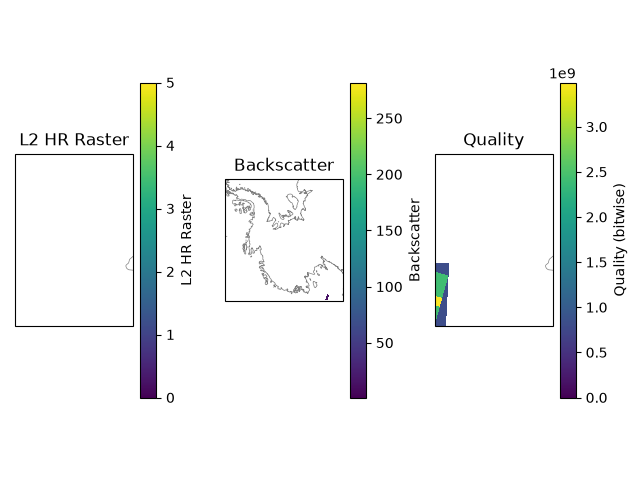

In [7]:
# PLOT HR footprint and LR data to confirm overlap
plt.close('all')
proj = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
pc = ccrs.PlateCarree()
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={"projection": proj})

# colors
cmap = "viridis"
vmin, vmax = 0, 5
pad = 1.0  # pad map extent

# plot HR raster values
ax1.coastlines(resolution="10m", linewidth=0.5, color="gray")
# ax1.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
utm = ccrs.UTM(zone=d_HR.utm_zone_num, southern_hemisphere=True)
hr_x, hr_y = np.meshgrid(d_HR["x"].values, d_HR["y"].values)
hr_mesh = ax1.pcolormesh(hr_x, hr_y, d_HR["wse"].values, transform=utm, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto", zorder=2)
fig.colorbar(hr_mesh, ax=ax1, label="L2 HR Raster", shrink=0.7, pad=0.05)
ax1.set_extent([lonmin - pad, lonmax + pad, latmin - pad, latmax + pad], crs=pc)
ax1.set_title(f"L2 HR Raster")

# plot HR raster values
ax2.coastlines(resolution="10m", linewidth=0.5, color="gray")
# ax2.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
utm = ccrs.UTM(zone=d_HR.utm_zone_num, southern_hemisphere=True)
hr_mesh2 = ax2.pcolormesh(hr_x, hr_y, d_HR["sig0"].values, transform=utm, cmap=cmap, vmin=np.nanmin(d_HR["sig0"].values), vmax=np.nanmax(d_HR["sig0"].values), shading="auto", zorder=2)
fig.colorbar(hr_mesh2, ax=ax2, label="Backscatter", shrink=0.7, pad=0.05)
ax2.set_extent([lonmin - pad, lonmax + pad, latmin - pad, latmax + pad], crs=pc)
ax2.set_title(f"Backscatter")

# plot HR raster values
ax3.coastlines(resolution="10m", linewidth=0.5, color="gray")
# ax3.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
utm = ccrs.UTM(zone=d_HR.utm_zone_num, southern_hemisphere=True)
hr_mesh3 = ax3.pcolormesh(hr_x, hr_y, d_HR["wse_qual_bitwise"].values, transform=utm, cmap=cmap, vmin=np.nanmin(d_HR["wse_qual_bitwise"].values), vmax=np.nanmax(d_HR["wse_qual_bitwise"].values), shading="auto", zorder=2)
fig.colorbar(hr_mesh3, ax=ax3, label="Quality (bitwise)", shrink=0.7, pad=0.05)
ax3.set_extent([lonmin - pad, lonmax + pad, latmin - pad, latmax + pad], crs=pc)
ax3.set_title(f"Quality")

plt.tight_layout()
plt.show()



## Get Accompanying LR data using HR footprint/time ##

In [8]:
### Pick the LR granule closest in time to the HR granule
def lr_start_time(granule):
    t = granule["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"]
    return datetime.fromisoformat(t.replace("Z", ""))
    
LR_results = earthaccess.search_data(
    short_name=LR_SHORT_NAME,
    temporal=(time1, time2), # same time1/time2 as for HR data
    bounding_box=SBOX        # same bbox as for HR data
)

print(f'{len(LR_results)} total granules found.')
print()
for g in LR_results:
    print(g['umm']['TemporalExtent'])

# compare times and return best gradule temporally
lr_times = [lr_start_time(g) for g in LR_results]
diffs = [abs((t - hr_time).total_seconds()) for t in lr_times] # compare to HR times
best_idx = int(np.argmin(diffs))
print(f"\nBest LR match: index {best_idx}, time {lr_times[best_idx]}, "
      f"Δt = {diffs[best_idx]/60:.1f} min from HR")

Granules found: 1
1 total granules found.

{'RangeDateTime': {'EndingDateTime': '2026-02-05T12:43:50.693Z', 'BeginningDateTime': '2026-02-05T11:51:53.037Z'}}

Best LR match: index 0, time 2026-02-05 11:51:53.037000, Δt = 103.7 min from HR


In [9]:
# Open best LR dataset
LR_files = earthaccess.open([LR_results[best_idx]])
d_LR = xr.open_dataset(LR_files[0])

lr_lon = d_LR["longitude"].values.ravel()
lr_lat = d_LR["latitude"].values.ravel()
valid = np.isfinite(lr_lon) & np.isfinite(lr_lat)
lr_lon, lr_lat = lr_lon[valid], lr_lat[valid] # filter nan values
ssh_raw = d_LR["ssh_karin"].values.ravel()[valid]
print(np.nanmedian(ssh_raw))
ssh_cor = ssh_raw + d_LR["height_cor_xover"].values.ravel()[valid]
print(np.nanmedian(ssh_cor))

print(f"LR footprint: lon [{lr_lon.min():.3f}, {lr_lon.max():.3f}], "
      f"lat [{lr_lat.min():.3f}, {lr_lat.max():.3f}]")

 Opening 1 granules, approx size: 0.01 GB


QUEUEING TASKS | : 0it [00:00, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

-12.9295
-12.83635
LR footprint: lon [169.189, 336.634], lat [-78.272, 78.272]


## Plot HR footprint and LR data to confirm overlap ##

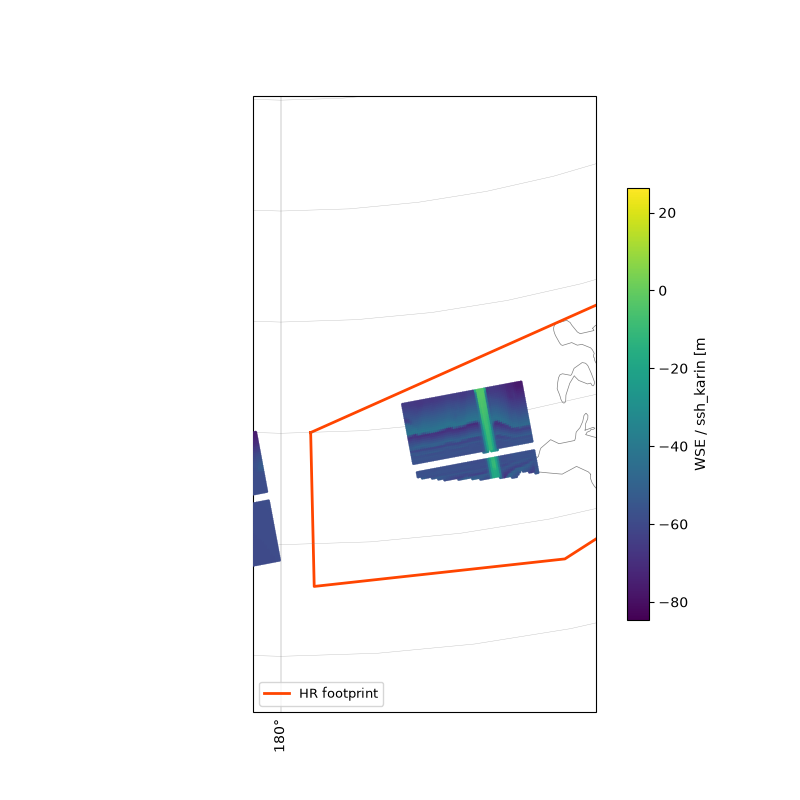

In [10]:
# PLOT HR footprint and LR data to confirm overlap
proj = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
pc = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=proj)

# add coastline and land features
ax.coastlines(resolution="10m", linewidth=0.5, color="gray")

# corrections
ssh_cor = ssh_raw + d_LR["height_cor_xover"].values.ravel()[valid]
d_HR["wse_corr"] = d_HR["wse"] + d_HR["geoid"]

# plot search bounding box
# ax.plot(bbox_lon, bbox_lat, transform=pc, color="black", linewidth=2, linestyle="--", label="Search bbox")

# plot returned HR footprint outline
ax.plot(hr_fp_lon, hr_fp_lat, transform=pc, color="orangered", linewidth=2, label="HR footprint")

# shared color scale for both HR and LR
cmap = "viridis"
vmin = min(np.nanmin(d_HR["wse_corr"].values), np.nanmin(ssh_cor))
vmax = max(np.nanmax(d_HR["wse_corr"].values), np.nanmax(ssh_cor))
# plot HR raster values
utm = ccrs.UTM(zone=d_HR.utm_zone_num, southern_hemisphere=True)
hr_x, hr_y = np.meshgrid(d_HR["x"].values, d_HR["y"].values)
hr_mesh = ax.pcolormesh(hr_x, hr_y, d_HR["wse_corr"].values, transform=utm, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto", zorder=2)

# plot LR SSH, using the same color scale
sc = ax.scatter(lr_lon, lr_lat, c=ssh_cor, cmap=cmap, vmin=vmin, vmax=vmax, s=5, transform=pc, zorder=3, linewidths=0.2)

# one shared colorbar for both
plt.colorbar(hr_mesh, ax=ax, label="WSE / ssh_karin [m", shrink=0.7, pad=0.05)

pad = 2.0  # pad map extent
ax.set_extent([lonmin - pad, lonmax + pad, latmin - pad, latmax + pad], crs=pc)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.legend(loc="lower left", fontsize=9)
ax.set_title(f"HR wse vs LR ssh_karin (no corrections)\n{lr_times[best_idx]:%Y-%m-%d %H:%M}", fontsize=11)
plt.show()


In [11]:
plt.close('all')

In [12]:
d_LR

<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-02-06T22:03:45Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       67.29363843296993
    ssha_variance:                                 1.4729401095877612
    references:                                    V1.4.1
    equator_longitude:                             -107.09

## Calculate Differences ##

In [13]:
# calculate differences
# Reproject LR lon/lat into HR's UTM x/y
utm = ccrs.UTM(zone=d_HR.utm_zone_num, southern_hemisphere=True)

# Reproject LR lon/lat into HR's UTM x/y
lr_xy = utm.transform_points(pc, lr_lon, lr_lat)
lr_x, lr_y = lr_xy[:, 0], lr_xy[:, 1]

# Build a KD-tree of HR pixel centers (raw wse, untouched)
hr_x, hr_y = np.meshgrid(d_HR["x"].values, d_HR["y"].values)
hr_wse_flat = d_HR["wse_corr"].values.ravel()
valid_hr = np.isfinite(hr_wse_flat)
hr_points = np.column_stack([hr_x.ravel()[valid_hr], hr_y.ravel()[valid_hr]])
tree = cKDTree(hr_points)

# For each LR point, average nearby HR pixels within ~1 km (roughly half the LR footprint)
search_radius_m = 1000
rows = []
for lon_i, lat_i, xi, yi, ssh_i in zip(lr_lon, lr_lat, lr_x, lr_y, ssh_raw):
    if not np.isfinite(ssh_i):
        continue
    idx = tree.query_ball_point([xi, yi], r=search_radius_m)
    if not idx:
        continue
    hr_local_mean = np.nanmean(hr_wse_flat[valid_hr][idx])
    rows.append({
        "lon": lon_i, "lat": lat_i, "x": xi, "y": yi,
        "hr_wse_corr": hr_local_mean,
        "lr_ssh_corr": ssh_i,
        "diff_lr_minus_hr": ssh_i - hr_local_mean,
    })

diff_df = pd.DataFrame(rows)
print(f"{len(diff_df)} LR points matched to nearby HR pixels")
print(diff_df["diff_lr_minus_hr"].describe())

1576 LR points matched to nearby HR pixels
count    1576.000000
mean        1.492101
std         4.125843
min        -2.084331
25%        -0.595771
50%         0.541340
75%         1.295294
max        19.912817
Name: diff_lr_minus_hr, dtype: float64


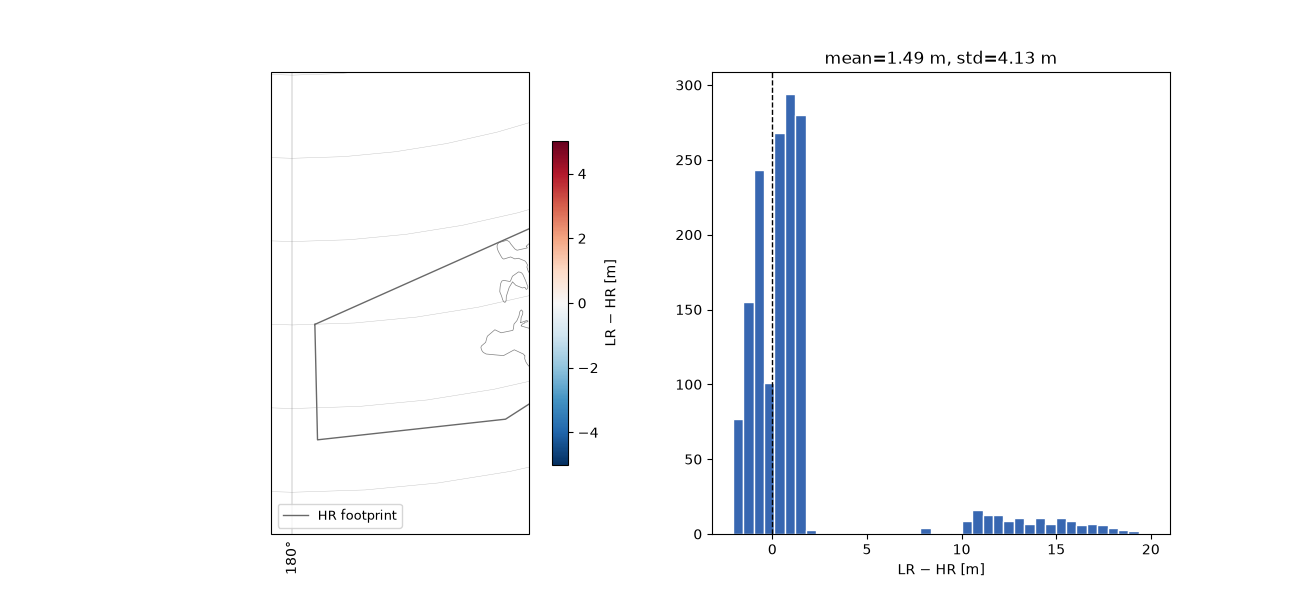

In [14]:
fig, axes = plt.subplot_mosaic(
    [["map", "hist"]],
    figsize=(13, 6),
    per_subplot_kw={"map": {"projection": proj}},
)

ax = axes["map"]
ax.coastlines(resolution="10m", linewidth=0.5, color="gray")
# ax.plot(bbox_lon, bbox_lat, transform=pc, color="black", linewidth=2, linestyle="--", label="Search bbox")
ax.plot(hr_fp_lon, hr_fp_lat, transform=pc, color="dimgray", linewidth=1, label="HR footprint")

sc = ax.scatter(diff_df["lon"], diff_df["lat"], c=diff_df["diff_lr_minus_hr"], cmap="RdBu_r", vmin=-5, vmax=5, s=8, transform=pc, zorder=3)
plt.colorbar(sc, ax=ax, label="LR − HR [m]", shrink=0.7, pad=0.05)

ax.set_extent([lonmin - pad, lonmax + pad, latmin - pad, latmax + pad], crs=pc)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False
ax.legend(loc="lower left", fontsize=9)
ax.set_title("Raw diff (no corrections applied)")

axes["hist"].hist(diff_df["diff_lr_minus_hr"].dropna(), bins=40, color="#3867B1", edgecolor="white")
axes["hist"].axvline(0, color="black", linewidth=1, linestyle="--")
axes["hist"].set_xlabel("LR − HR [m]")
axes["hist"].set_title(f"mean={diff_df['diff_lr_minus_hr'].mean():.2f} m, std={diff_df['diff_lr_minus_hr'].std():.2f} m")
plt.show()

As you can see, there are lots of outliers and data quality issues, not to mention that we have not applied any geoid, tidal, or other corrections. 

In [ ]:
def xy2ll(x, y):
    """Convert PS71 (EPSG:3031) coordinates to WGS84 (EPSG:4326)"""
    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    xy_to_ll = Transformer.from_crs(crs_xy, crs_ll, always_xy=True)
    lon, lat = xy_to_ll.transform(x, y)
    return lon, lat

# Convert the region AOI to lat/lon once, for masking pixel-level lat/lon fields below
corners_x = [RAME_BBOX[0], RAME_BBOX[2], RAME_BBOX[2], RAME_BBOX[0]]
corners_y = [RAME_BBOX[1], RAME_BBOX[1], RAME_BBOX[3], RAME_BBOX[3]]
corner_lons, corner_lats = xy2ll(np.array(corners_x), np.array(corners_y))
LON_MIN, LON_MAX = float(corner_lons.min()), float(corner_lons.max())
LAT_MIN, LAT_MAX = float(corner_lats.min()), float(corner_lats.max())
print(f"Rame region: lon [{LON_MIN:.4f}, {LON_MAX:.4f}], lat [{LAT_MIN:.4f}, {LAT_MAX:.4f}]")


::::{admonition} Why HR needs an external ocean tide model, and LR doesn't
:class: tip
To bring HR to the same physical reference as LR, we compute
the tide ourselves with `pyTMD` and the regional **CATS2008-v2023**
Antarctic ocean tide model — the same approach used in the SWOT-vs-ICESat2
comparison tutorial.

The rest of the correction chain is otherwise symmetric:

```
wse_HR = H - solid_earth_tide - load_tide_fes - pole_tide - ocean_tide(CATS2008)
wse_LR = ssh_karin - solid_earth_tide - pole_tide - ocean_tide_fes(built-in)
```

`solid_earth_tide` and `pole_tide` come from each product's own fields
directly; only the ocean tide term is sourced differently between the two.
::::